# RoBERTa - Dataset (sexism-detection-english-text)

In [1]:
!pip install -q transformers datasets scikit-learn matplotlib seaborn wordcloud

In [2]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import RobertaTokenizer, RobertaForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW
from sklearn.metrics import confusion_matrix, classification_report, f1_score
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import os

os.makedirs('/content/models/roberta_ddet', exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

MODEL_NAME = 'roberta-base'
MAX_LEN = 128
BATCH_SIZE = 16
EPOCHS = 2
LR = 2e-5
SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)

Device: cuda


In [3]:
train_df = pd.read_csv('/content/train.csv')
dev_df = pd.read_csv('/content/dev.csv')
test_df = pd.read_csv('/content/test.csv')

print('Train:', train_df['label'].value_counts().to_dict())
print('Dev:', dev_df['label'].value_counts().to_dict())
print('Test:', test_df['label'].value_counts().to_dict())

Train: {0: 10602, 1: 3398}
Dev: {0: 1514, 1: 486}
Test: {0: 3030, 1: 970}


In [4]:
tokenizer = RobertaTokenizer.from_pretrained(MODEL_NAME)

class SexismDataset(Dataset):
    def __init__(self, df, tokenizer, max_len):
        self.texts = df['text'].tolist()
        self.labels = df['label'].tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_loader = DataLoader(SexismDataset(train_df, tokenizer, MAX_LEN), batch_size=BATCH_SIZE, shuffle=True)
dev_loader = DataLoader(SexismDataset(dev_df, tokenizer, MAX_LEN), batch_size=BATCH_SIZE)
test_loader = DataLoader(SexismDataset(test_df, tokenizer, MAX_LEN), batch_size=BATCH_SIZE)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [5]:
classes = np.unique(train_df['label'].values)
weights = compute_class_weight('balanced', classes=classes, y=train_df['label'].values)
class_weights_tensor = torch.tensor(weights, dtype=torch.float).to(DEVICE)

model = RobertaForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
model = model.to(DEVICE)

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=total_steps // 5, num_training_steps=total_steps)
loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights_tensor)

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [6]:
train_losses, val_losses, val_f1s = [], [], []
best_val_f1 = 0
best_val_loss = float('inf')
patience_counter = 0
PATIENCE = 1

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()
        ids = batch['input_ids'].to(DEVICE)
        mask = batch['attention_mask'].to(DEVICE)
        labels = batch['label'].to(DEVICE)
        logits = model(input_ids=ids, attention_mask=mask).logits
        loss = loss_fn(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        running_loss += loss.item()
    train_losses.append(running_loss / len(train_loader))

    model.eval()
    val_loss_sum, all_preds, all_labels = 0, [], []
    with torch.no_grad():
        for batch in dev_loader:
            ids = batch['input_ids'].to(DEVICE)
            mask = batch['attention_mask'].to(DEVICE)
            labels = batch['label'].to(DEVICE)
            logits = model(input_ids=ids, attention_mask=mask).logits
            val_loss_sum += loss_fn(logits, labels).item()
            all_preds.extend(logits.argmax(dim=1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    val_losses.append(val_loss_sum / len(dev_loader))
    vf1 = f1_score(all_labels, all_preds, average='macro')
    val_f1s.append(vf1)

    print(f'Epoch {epoch+1}/{EPOCHS} train_loss={train_losses[-1]:.4f} val_loss={val_losses[-1]:.4f} val_f1={vf1:.4f}')

    if vf1 > best_val_f1:
        best_val_f1 = vf1
        model.save_pretrained('/content/models/roberta_ddet')
        tokenizer.save_pretrained('/content/models/roberta_ddet')

    if val_losses[-1] < best_val_loss:
        best_val_loss = val_losses[-1]
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print('Early stopping triggered')
            break

print(f'Best val F1: {best_val_f1:.4f}')

Epoch 1/2 train_loss=0.5032 val_loss=0.3899 val_f1=0.7932


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 2/2 train_loss=0.3286 val_loss=0.3916 val_f1=0.8181


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Early stopping triggered.
Best val F1: 0.8181


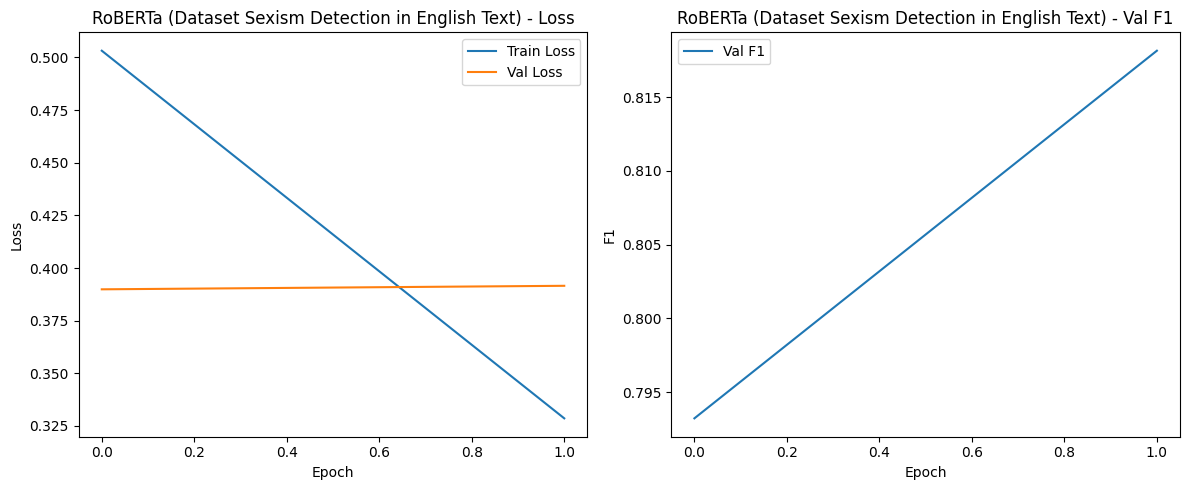

In [7]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('RoBERTa (Dataset Sexism Detection in English Text) - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(val_f1s, label='Val F1')
plt.title('RoBERTa (Dataset Sexism Detection in English Text) - Val F1')
plt.xlabel('Epoch')
plt.ylabel('F1')
plt.legend()
plt.tight_layout()
plt.savefig('/content/models/roberta_ddet/training_history.png', dpi=150)
plt.show()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

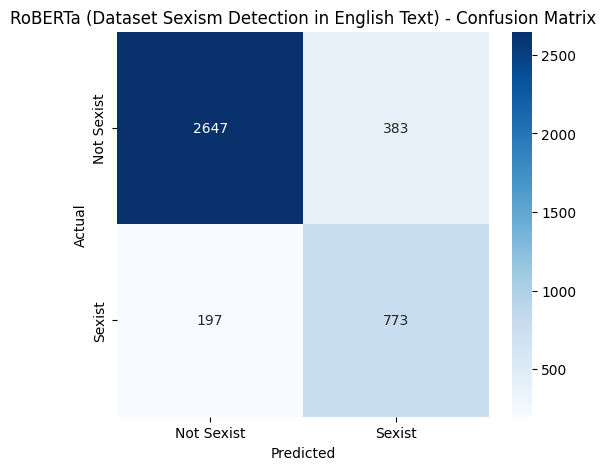

              precision    recall  f1-score   support

  Not Sexist       0.93      0.87      0.90      3030
      Sexist       0.67      0.80      0.73       970

    accuracy                           0.85      4000
   macro avg       0.80      0.84      0.81      4000
weighted avg       0.87      0.85      0.86      4000



In [8]:
best_model = RobertaForSequenceClassification.from_pretrained('/content/models/roberta_ddet').to(DEVICE)
best_model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for batch in test_loader:
        ids = batch['input_ids'].to(DEVICE)
        mask = batch['attention_mask'].to(DEVICE)
        logits = best_model(input_ids=ids, attention_mask=mask).logits
        all_preds.extend(logits.argmax(dim=1).cpu().numpy())
        all_labels.extend(batch['label'].numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Sexist', 'Sexist'], yticklabels=['Not Sexist', 'Sexist'])
plt.title('RoBERTa (Dataset Sexism Detection in English Text) - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('/content/models/roberta_ddet/confusion_matrix.png', dpi=150)
plt.show()

report = classification_report(all_labels, all_preds, target_names=['Not Sexist', 'Sexist'])
print(report)

with open('/content/models/roberta_ddet/metrics.txt', 'w') as f:
    f.write(report)
    f.write('\nConfusion Matrix:\n')
    f.write(str(cm))

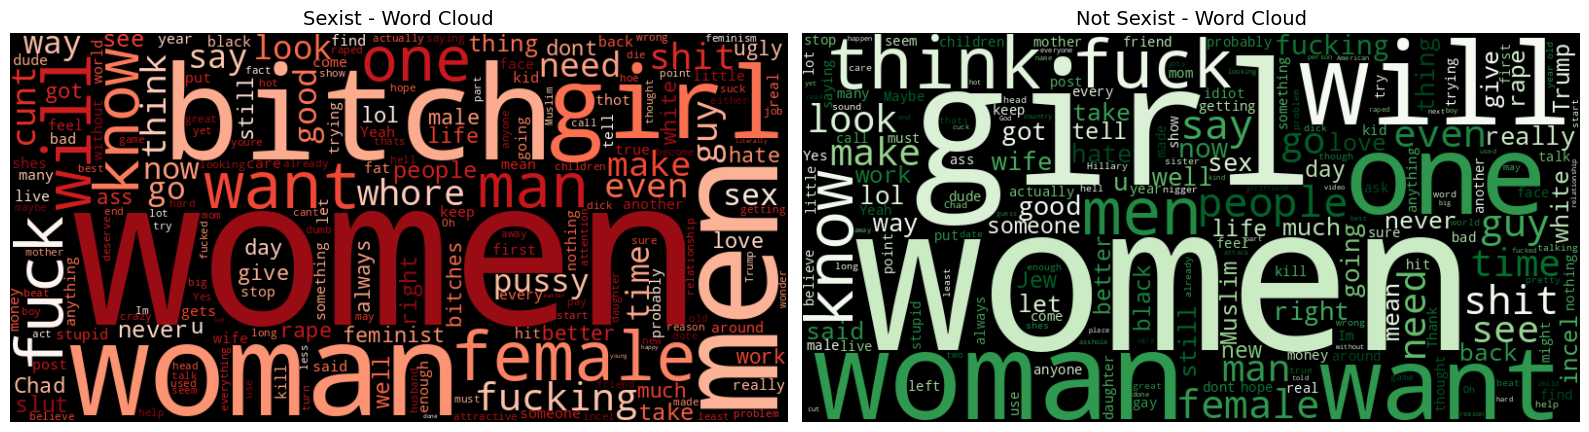

In [9]:
all_df = pd.concat([train_df, dev_df, test_df])
sexist_text = ' '.join(all_df[all_df['label'] == 1]['text'].tolist())
clean_text = ' '.join(all_df[all_df['label'] == 0]['text'].tolist())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(WordCloud(width=800, height=400, background_color='black', colormap='Reds').generate(sexist_text), interpolation='bilinear')
axes[0].set_title('Sexist - Word Cloud', fontsize=14)
axes[0].axis('off')
axes[1].imshow(WordCloud(width=800, height=400, background_color='black', colormap='Greens').generate(clean_text), interpolation='bilinear')
axes[1].set_title('Not Sexist - Word Cloud', fontsize=14)
axes[1].axis('off')
plt.tight_layout()
plt.savefig('/content/models/roberta_ddet/wordclouds.png', dpi=150)
plt.show()

In [10]:
import shutil
shutil.make_archive('/content/roberta_ddet_results', 'zip', '/content/models/roberta_ddet')

'/content/roberta_ddet_results.zip'